<center><img src="car.jpg" width=500></center>


Insurance companies invest a lot of time and money into optimizing their pricing and accurately estimating the likelihood that customers will make a claim. In many countries insurance it is a legal requirement to have car insurance in order to drive a vehicle on public roads, so the market is very large!

(`Source: https://www.accenture.com/_acnmedia/pdf-84/accenture-machine-leaning-insurance.pdf`) 

Knowing all of this, On the Road car insurance have requested your services in building a model to predict whether a customer will make a claim on their insurance during the policy period. As they have very little expertise and infrastructure for deploying and monitoring machine learning models, they've asked you to identify the single feature that results in the best performing model, as measured by accuracy, so they can start with a simple model in production.

They have supplied you with their customer data as a csv file called `car_insurance.csv`, along with a table detailing the column names and descriptions below.



## The dataset

| Column | Description |
|--------|-------------|
| `id` | Unique client identifier |
| `age` | Client's age: <br> <ul><li>`0`: 16-25</li><li>`1`: 26-39</li><li>`2`: 40-64</li><li>`3`: 65+</li></ul> |
| `gender` | Client's gender: <br> <ul><li>`0`: Female</li><li>`1`: Male</li></ul> |
| `driving_experience` | Years the client has been driving: <br> <ul><li>`0`: 0-9</li><li>`1`: 10-19</li><li>`2`: 20-29</li><li>`3`: 30+</li></ul> |
| `education` | Client's level of education: <br> <ul><li>`0`: No education</li><li>`1`: High school</li><li>`2`: University</li></ul> |
| `income` | Client's income level: <br> <ul><li>`0`: Poverty</li><li>`1`: Working class</li><li>`2`: Middle class</li><li>`3`: Upper class</li></ul> |
| `credit_score` | Client's credit score (between zero and one) |
| `vehicle_ownership` | Client's vehicle ownership status: <br><ul><li>`0`: Does not own their vehilce (paying off finance)</li><li>`1`: Owns their vehicle</li></ul> |
| `vehcile_year` | Year of vehicle registration: <br><ul><li>`0`: Before 2015</li><li>`1`: 2015 or later</li></ul> |
| `married` | Client's marital status: <br><ul><li>`0`: Not married</li><li>`1`: Married</li></ul> |
| `children` | Client's number of children |
| `postal_code` | Client's postal code | 
| `annual_mileage` | Number of miles driven by the client each year |
| `vehicle_type` | Type of car: <br> <ul><li>`0`: Sedan</li><li>`1`: Sports car</li></ul> |
| `speeding_violations` | Total number of speeding violations received by the client | 
| `duis` | Number of times the client has been caught driving under the influence of alcohol |
| `past_accidents` | Total number of previous accidents the client has been involved in |
| `outcome` | Whether the client made a claim on their car insurance (response variable): <br><ul><li>`0`: No claim</li><li>`1`: Made a claim</li></ul> |

In [66]:
# Import required modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.formula.api import logit


1 - Reading in and exploring the dataset

In [67]:
insurance = pd.read_csv('car_insurance.csv')
print('N° of Rows:',insurance.shape[0])
print('N° of Columns:',insurance.shape[1])
print(insurance.info())

N° of Rows: 10000
N° of Columns: 18
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   10000 non-null  int64  
 1   age                  10000 non-null  int64  
 2   gender               10000 non-null  int64  
 3   driving_experience   10000 non-null  object 
 4   education            10000 non-null  object 
 5   income               10000 non-null  object 
 6   credit_score         9018 non-null   float64
 7   vehicle_ownership    10000 non-null  float64
 8   vehicle_year         10000 non-null  object 
 9   married              10000 non-null  float64
 10  children             10000 non-null  float64
 11  postal_code          10000 non-null  int64  
 12  annual_mileage       9043 non-null   float64
 13  vehicle_type         10000 non-null  object 
 14  speeding_violations  10000 non-null  int64  
 15  d

In [68]:
insurance.describe()

,id,age,gender,credit_score,vehicle_ownership,married,children,postal_code,annual_mileage,speeding_violations,duis,past_accidents,outcome
count,10000.000000,10000.000000,10000.000000,9018.000000,10000.000000,10000.000000,10000.000000,10000.000000,9043.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,500521.906800,1.489500,0.499000,0.515813,0.697000,0.498200,0.688800,19864.548400,11697.003207,1.482900,0.23920,1.056300,0.313300
std,290030.768758,1.025278,0.500024,0.137688,0.459578,0.500022,0.463008,18915.613855,2818.434528,2.241966,0.55499,1.652454,0.463858
min,101.000000,0.000000,0.000000,0.053358,0.000000,0.000000,0.000000,10238.000000,2000.000000,0.000000,0.00000,0.000000,0.000000
25%,249638.500000,1.000000,0.000000,0.417191,0.000000,0.000000,0.000000,10238.000000,10000.000000,0.000000,0.00000,0.000000,0.000000
50%,501777.000000,1.000000,0.000000,0.525033,1.000000,0.000000,1.000000,10238.000000,12000.000000,0.000000,0.00000,0.000000,0.000000
75%,753974.500000,2.000000,1.000000,0.618312,1.000000,1.000000,1.000000,32765.000000,14000.000000,2.000000,0.00000,2.000000,1.000000
max,999976.000000,3.000000,1.000000,0.960819,1.000000,1.000000,1.000000,92101.000000,22000.000000,22.000000,6.00000,15.000000,1.000000


In [69]:
insurance.head()

,id,age,gender,driving_experience,education,income,credit_score,vehicle_ownership,vehicle_year,married,children,postal_code,annual_mileage,vehicle_type,speeding_violations,duis,past_accidents,outcome
0,569520,3,0,0-9y,high school,upper class,0.629027,1.0,after 2015,0.0,1.0,10238,12000.0,sedan,0,0,0,0.0
1,750365,0,1,0-9y,none,poverty,0.357757,0.0,before 2015,0.0,0.0,10238,16000.0,sedan,0,0,0,1.0
2,199901,0,0,0-9y,high school,working class,0.493146,1.0,before 2015,0.0,0.0,10238,11000.0,sedan,0,0,0,0.0
3,478866,0,1,0-9y,university,working class,0.206013,1.0,before 2015,0.0,1.0,32765,11000.0,sedan,0,0,0,0.0
4,731664,1,1,10-19y,none,working class,0.388366,1.0,before 2015,0.0,0.0,32765,12000.0,sedan,2,0,1,1.0


2 - Filling missing Values

In [70]:
null_counts = insurance.isnull().sum()
print(null_counts[null_counts >0]) # Printing just the columns with null values

credit_score      982
annual_mileage    957
dtype: int64


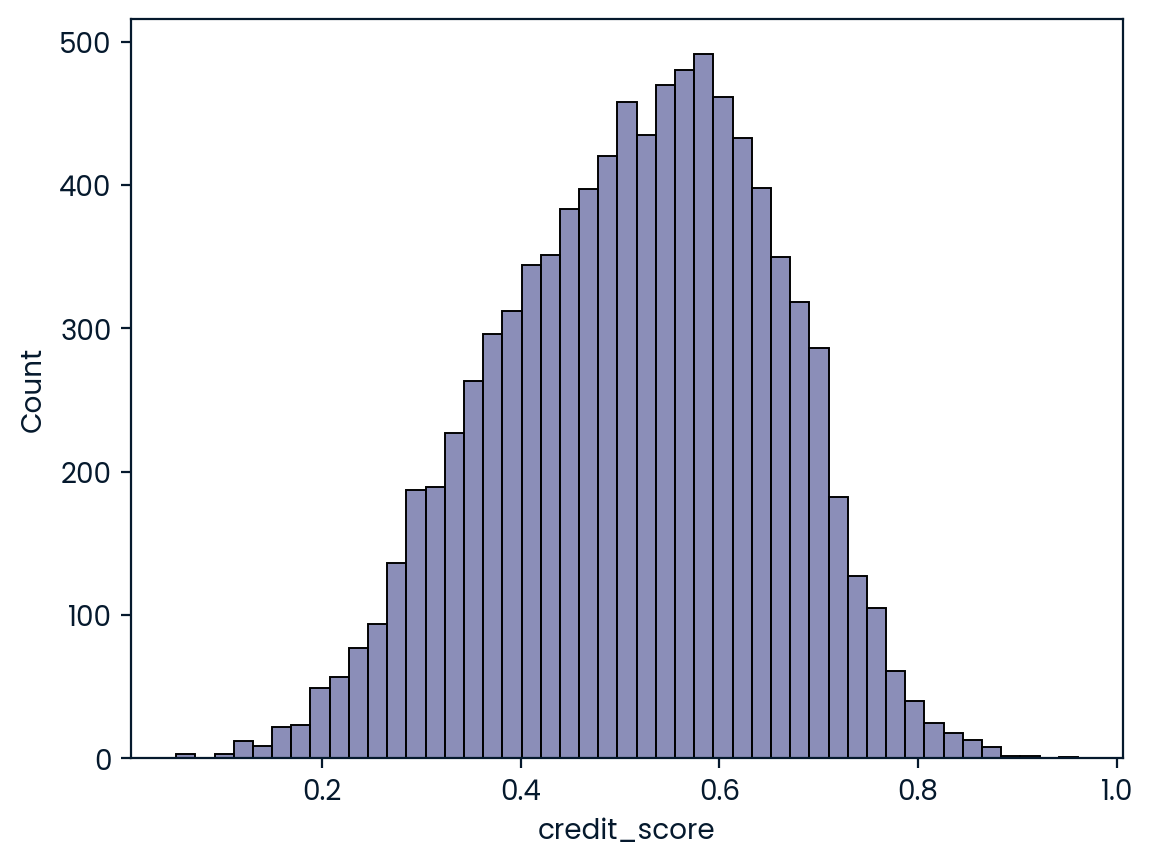

In [71]:
sns.histplot(insurance['credit_score'])
plt.show()

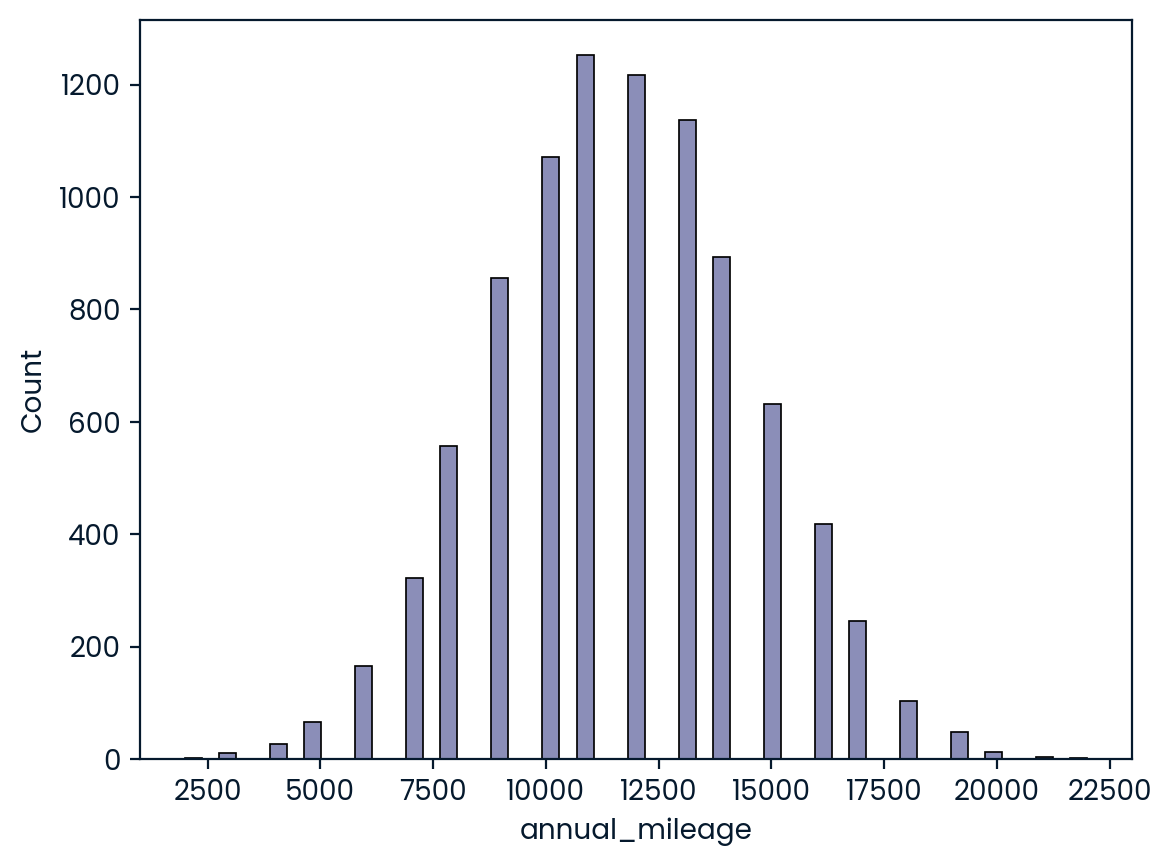

In [72]:
sns.histplot(insurance['annual_mileage'])
plt.show()

In [73]:
# Since both columns exhibit a normal distribution, the null values will be imputed with the mean

insurance['credit_score'] = insurance['credit_score'].fillna(insurance['credit_score'].mean())
insurance['annual_mileage'] = insurance['annual_mileage'].fillna(insurance['annual_mileage'].mean())


In [74]:
print(insurance.isnull().sum()) # no more null values

id                     0
age                    0
gender                 0
driving_experience     0
education              0
income                 0
credit_score           0
vehicle_ownership      0
vehicle_year           0
married                0
children               0
postal_code            0
annual_mileage         0
vehicle_type           0
speeding_violations    0
duis                   0
past_accidents         0
outcome                0
dtype: int64


3. Preparing for modeling

In [75]:
models = []  # Creating a list to store the models

# Storing the features as a variable excluding 'outcome' & 'id'
features = insurance.drop(columns=['outcome', 'id']).columns  
target = 'outcome'  # Store the target column as a string

# Loop through each feature and fit a logistic regression model
for col in features:
    formula = f"{target} ~ {col}"  # Create formula as "outcome ~ feature"
    
    model = logit(formula, data=insurance).fit(disp=False)  # Fit logistic regression model
    models.append(model)  # Store model in the list
    print(f"Trained Logistic Regression Model for {col}")


Trained Logistic Regression Model for age
Trained Logistic Regression Model for gender
Trained Logistic Regression Model for driving_experience
Trained Logistic Regression Model for education
Trained Logistic Regression Model for income
Trained Logistic Regression Model for credit_score
Trained Logistic Regression Model for vehicle_ownership
Trained Logistic Regression Model for vehicle_year
Trained Logistic Regression Model for married
Trained Logistic Regression Model for children
Trained Logistic Regression Model for postal_code
Trained Logistic Regression Model for annual_mileage
Trained Logistic Regression Model for vehicle_type
Trained Logistic Regression Model for speeding_violations
Trained Logistic Regression Model for duis
Trained Logistic Regression Model for past_accidents


4 Measuring performance

In [76]:
accuracies = []  # List to store model accuracies

# Loop through each trained model using the index
for i in range(len(models)):  
    model = models[i]  # Select model at index i
    conf_matrix = model.pred_table()  # Create confusion matrix

    # Extract TN, TP, FN, FP from the confusion matrix
    TN = conf_matrix[0, 0]  # True Negatives (Top-left)
    TP = conf_matrix[1, 1]  # True Positives (Bottom-right)
    FN = conf_matrix[1, 0]  # False Negatives (Bottom-left)
    FP = conf_matrix[0, 1]  # False Positives (Top-right)

    # Calculate accuracy
    accuracy = (TN + TP) / (TN + TP + FN + FP)
    accuracies.append(accuracy)  # Store accuracy in the list

    print(f"Model {i+1} Accuracy: {accuracy:.4f}")


Model 1 Accuracy: 0.7747
Model 2 Accuracy: 0.6867
Model 3 Accuracy: 0.7771
Model 4 Accuracy: 0.6867
Model 5 Accuracy: 0.7425
Model 6 Accuracy: 0.7054
Model 7 Accuracy: 0.7351
Model 8 Accuracy: 0.6867
Model 9 Accuracy: 0.6867
Model 10 Accuracy: 0.6867
Model 11 Accuracy: 0.6867
Model 12 Accuracy: 0.6904
Model 13 Accuracy: 0.6867
Model 14 Accuracy: 0.6867
Model 15 Accuracy: 0.6867
Model 16 Accuracy: 0.6867


5. Finding the best performing model

In [77]:
# Identify the index of the highest accuracy
best_index = accuracies.index(max(accuracies))  # Find index of highest accuracy

# Identify the best performing feature
best_feature = features[best_index]
best_accuracy = accuracies[best_index]

# Store results in a DataFrame
best_feature_df = pd.DataFrame({
    "best_feature": best_feature,  
    "best_accuracy": best_accuracy  
}, index=[0])  # Set index to 0

# Display the DataFrame
print(best_model_df)

         best_feature  best_accuracy
0  driving_experience         0.7771
